# 06 — Optuna Hyperparameter Tuning (Lesson)

## Learning Objectives
- Understand **why** each mathematical term appears and how it changes optimization/generalization.
- Apply the technique to both classification and regression.
- Compare synthetic and real-data behavior with reproducible experiments.

## Driving Question
> How do we optimize hyperparameters efficiently under compute constraints?

## Notebook Roadmap
Math (LaTeX) -> Synthetic Data -> Real Data (MNIST/California Housing) -> Visualizations -> Best Practices -> Exercises

### Mathematical Foundation (First Principles)

Hyperparameter optimization solves:

$$
\lambda^* = \arg\min_{\lambda \in \Lambda} \mathcal{V}(\lambda)
$$

where $\mathcal{V}(\lambda)$ is validation objective after training with hyperparameters $\lambda$.

Optuna uses adaptive sampling and pruning to reduce wasted trials.

**Why this helps**
- Prioritizes promising regions of search space.
- Stops weak trials early to reallocate compute.
- Improves reproducible tuning workflows.

### Deep Equation Lineage (Term-by-Term)

We now connect every lesson to the same first-principles optimization pipeline.

1. **Population objective** (what we really care about):
$$
\mathcal{R}(\theta)=\mathbb{E}_{(x,y)\sim\mathcal{D}}[\ell(f_\theta(x),y)]
$$
2. **Empirical approximation** (what we can compute):
$$
\hat{\mathcal{R}}(\theta)=\frac{1}{N}\sum_{i=1}^{N}\ell(f_\theta(x_i),y_i)
$$
3. **Mini-batch stochastic estimate** (what we optimize per step):
$$
g_t=\frac{1}{m}\sum_{i \in \mathcal{B}_t}\nabla_\theta \ell(f_\theta(x_i),y_i)
$$
4. **Chain-rule expansion** (how gradients flow through layers):
$$
\nabla_\theta \ell
=
\frac{\partial \ell}{\partial \hat{y}}
\cdot
\frac{\partial \hat{y}}{\partial h_L}
\cdot
\frac{\partial h_L}{\partial h_{L-1}}
\cdots
\frac{\partial h_1}{\partial \theta}
$$
5. **Regularized update** (how each lesson perturbs the step):
$$
\theta_{t+1}
=
\theta_t
-\eta\left(g_t+\nabla_\theta\Omega(\theta_t)\right)
$$

| Term | Meaning | Where it appears in code |
|---|---|---|
| $\eta$ | step size controlling update magnitude | optimizer learning rate |
| $g_t$ | stochastic gradient estimate | `loss.backward()` |
| $\Omega(\theta)$ | explicit/implicit regularization | weight decay, dropout, early stopping |
| $m$ | mini-batch size | `DataLoader(..., batch_size=...)` |
| $\hat{y}=f_\theta(x)$ | model predictions | `logits = model(xb)` |

**Interpretation checkpoint:** if training is unstable, inspect whether the issue comes from gradient scale ($g_t$), step size ($\eta$), or noisy estimation (small $m$).

### Before the Code: Purpose + Mechanics

This setup cell imports all libraries and sets deterministic seeds so differences across lessons are caused by techniques, not randomness.
Background: reproducibility is essential for comparing optimization methods, and explicit device selection explains hardware-dependent speedups.

In [1]:
# Core Python utilities for copy-safe checkpointing and numerical diagnostics.
import copy
import math
import random
from dataclasses import dataclass

# Scientific stack for array manipulation and plotting.
import numpy as np
import matplotlib.pyplot as plt

# PyTorch core modules.
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Classical ML utilities for controlled data generation and scaling.
from sklearn.datasets import make_classification, make_regression, fetch_california_housing
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Torchvision datasets for image experiments and Optuna for tuning.
from torchvision import datasets, transforms
import optuna

# Seed all major random generators so curves are comparable lesson-to-lesson.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Choose accelerator when available; this influences runtime but not algorithmic logic.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


/Users/ankitchimariya/.virtualenvs/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### After the Code: Background + Why It Can Help

When this cell runs, the notebook environment is fully reproducible and equipped for diagnostics (including confusion matrices).
Deterministic seeds improve interpretation quality because shifts in curves are more likely to come from method changes than random variation.

### Before the Code: Purpose + Mechanics

This cell defines the experiment configuration, a compact MLP, and helper regularization/initialization routines.
Background: the architecture is intentionally small to keep runtime practical while still exhibiting optimization pathologies and improvements.

In [2]:
# Dataclass keeps all tunable hyperparameters in one inspectable object.
@dataclass
class Config:
    hidden_dim: int = 128
    lr: float = 1e-3
    epochs: int = 8
    batch_size: int = 128
    dropout_p: float = 0.0
    use_batch_norm: bool = False
    init_scheme: str = 'default'
    weight_decay: float = 0.0
    l1_lambda: float = 0.0
    patience: int = 3


class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=128, use_batch_norm=False, dropout_p=0.0):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim)]  # First affine map from input to hidden representation.
        if use_batch_norm:
            layers.append(nn.BatchNorm1d(hidden_dim))  # Normalize hidden activations to stabilize gradient flow.
        layers += [nn.ReLU()]  # Nonlinearity allows composition beyond linear regression.
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))  # Stochastic masking reduces co-adaptation.

        layers.append(nn.Linear(hidden_dim, hidden_dim))  # Second hidden transformation for extra capacity.
        if use_batch_norm:
            layers.append(nn.BatchNorm1d(hidden_dim))
        layers += [nn.ReLU()]
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))

        layers.append(nn.Linear(hidden_dim, output_dim))  # Final projection to logits/regression output.
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def apply_initialization(model, scheme='default'):
    # Explicit initialization lets us test variance-preserving hypotheses directly.
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if scheme == 'xavier':
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
            elif scheme == 'kaiming':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)


def l1_penalty(model):
    # L1 adds sparsity pressure by summing absolute parameter magnitudes.
    return sum(p.abs().sum() for p in model.parameters())

### After the Code: Background + Why It Can Help

Running this cell establishes the controllable training object we will reuse across all datasets.
Because each lesson toggles only a few `Config` fields, changes in speed/stability/accuracy are easier to attribute causally.

### Before the Code: Purpose + Mechanics

This cell applies lesson-specific hyperparameter overrides while keeping the rest of the training pipeline fixed.
Background: controlled interventions are key to fair ablations in university-level experiments.

In [3]:
# Technique configuration for this lesson.
# Only the relevant controls are changed so observed behavior maps to lesson concepts.
# Keeping non-target hyperparameters fixed preserves a clean causal comparison.
cfg = Config(epochs=6, batch_size=128)
# Printing confirms the active knobs before any training side effects occur.
print(cfg)

Config(hidden_dim=128, lr=0.001, epochs=6, batch_size=128, dropout_p=0.0, use_batch_norm=False, init_scheme='default', weight_decay=0.0, l1_lambda=0.0, patience=3)


### After the Code: Background + Why It Can Help

You now have a single `cfg` object encoding the current lesson's inductive bias.
Small parameter changes can influence optimization geometry, gradient noise scale, and generalization gap.

### Before the Code: Purpose + Mechanics

These utilities implement the full optimization loop and attach diagnostics for gradient scale, parameter norm, and generalization gap.
Background: monitoring only loss can hide instability; richer traces explain why a method improves speed, stability, or accuracy.

In [4]:
def parameter_l2_norm(model):
    # Parameter norm helps diagnose under-regularization (exploding norm) vs over-regularization (collapsed norm).
    squared_sum = 0.0
    with torch.no_grad():
        for p in model.parameters():
            squared_sum += p.detach().pow(2).sum().item()
    return math.sqrt(squared_sum)


def run_epoch(model, loader, criterion, optimizer=None, task='classification', l1_lambda=0.0):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_correct, total_count = 0.0, 0, 0
    grad_norm_sum, grad_steps = 0.0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if is_train:
            optimizer.zero_grad()

        # Forward pass computes predictions from current parameters.
        logits = model(xb)
        if task == 'classification':
            loss = criterion(logits, yb)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
        else:
            yb = yb.float().unsqueeze(1)
            loss = criterion(logits, yb)

        # Add explicit L1 penalty term from the regularized objective.
        if l1_lambda > 0:
            loss = loss + l1_lambda * l1_penalty(model)

        if is_train:
            # Backprop builds d(loss)/d(theta) through chain rule over all layers.
            loss.backward()

            # Track batch gradient norm to quantify optimization stability.
            grad_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    grad_sq += p.grad.detach().pow(2).sum().item()
            grad_norm_sum += math.sqrt(grad_sq)
            grad_steps += 1

            # Optimizer uses gradient + learning rate + weight decay to update parameters.
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_count += xb.size(0)

    avg_loss = total_loss / max(total_count, 1)
    avg_grad_norm = grad_norm_sum / max(grad_steps, 1) if is_train else None
    if task == 'classification':
        return avg_loss, total_correct / max(total_count, 1), avg_grad_norm
    return avg_loss, None, avg_grad_norm


def fit(model, train_loader, val_loader, criterion, cfg, task='classification', use_early_stopping=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    best_state = copy.deepcopy(model.state_dict())
    best_val = float('inf')
    wait = 0

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_metric': [],
        'val_metric': [],
        'train_grad_norm': [],
        'param_norm': [],
        'generalization_gap': [],
    }
    best_epoch = 1
    stopped_epoch = cfg.epochs

    for epoch in range(cfg.epochs):
        tr_loss, tr_metric, tr_grad = run_epoch(model, train_loader, criterion, optimizer, task=task, l1_lambda=cfg.l1_lambda)
        va_loss, va_metric, _ = run_epoch(model, val_loader, criterion, optimizer=None, task=task, l1_lambda=cfg.l1_lambda)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_metric'].append(tr_metric)
        history['val_metric'].append(va_metric)
        history['train_grad_norm'].append(tr_grad)
        history['param_norm'].append(parameter_l2_norm(model))

        # Classification gap uses accuracy difference; regression gap uses loss difference.
        if task == 'classification' and tr_metric is not None and va_metric is not None:
            history['generalization_gap'].append(va_metric - tr_metric)
        else:
            history['generalization_gap'].append(va_loss - tr_loss)

        if va_loss < best_val - 1e-6:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            wait = 0
        else:
            wait += 1

        if use_early_stopping and wait >= cfg.patience:
            stopped_epoch = epoch + 1
            print(f'Early stop at epoch {epoch+1}; best val loss={best_val:.4f}')
            break

    history['best_epoch'] = best_epoch
    history['stopped_epoch'] = stopped_epoch
    model.load_state_dict(best_state)
    return history


def plot_history(history, title, metric_name='metric'):
    # Three coordinated views: objective trajectory, metric trajectory, and gradient/parameter dynamics.
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_title(f'{title} - loss')
    axes[0].set_xlabel('epoch')
    axes[0].legend()

    if history['train_metric'] and history['train_metric'][0] is not None:
        axes[1].plot(history['train_metric'], label='train')
        axes[1].plot(history['val_metric'], label='val')
        axes[1].set_title(f'{title} - {metric_name}')
        axes[1].set_xlabel('epoch')
        axes[1].legend()
    else:
        axes[1].axis('off')

    axes[2].plot(history['train_grad_norm'], label='grad norm')
    axes[2].plot(history['param_norm'], label='param norm')
    axes[2].set_title(f'{title} - optimization diagnostics')
    axes[2].set_xlabel('epoch')
    axes[2].legend()
    plt.tight_layout()
    plt.show()

### After the Code: Background + Why It Can Help

After executing these utilities, every experiment logs enough signals to reason about failure modes (e.g., noisy gradients, widening gap).
This improves educational depth by tying formulas directly to observable optimization behavior.

## Synthetic Data — Classification
We first isolate behavior on controllable synthetic data to build causal intuition before introducing dataset complexity.

### Before the Code: Purpose + Mechanics

This experiment creates a controlled binary classification problem, trains the lesson-specific model, and stores confidence/confusion diagnostics.
Background: synthetic data removes real-world noise so we can attribute performance differences to initialization/normalization/regularization decisions.

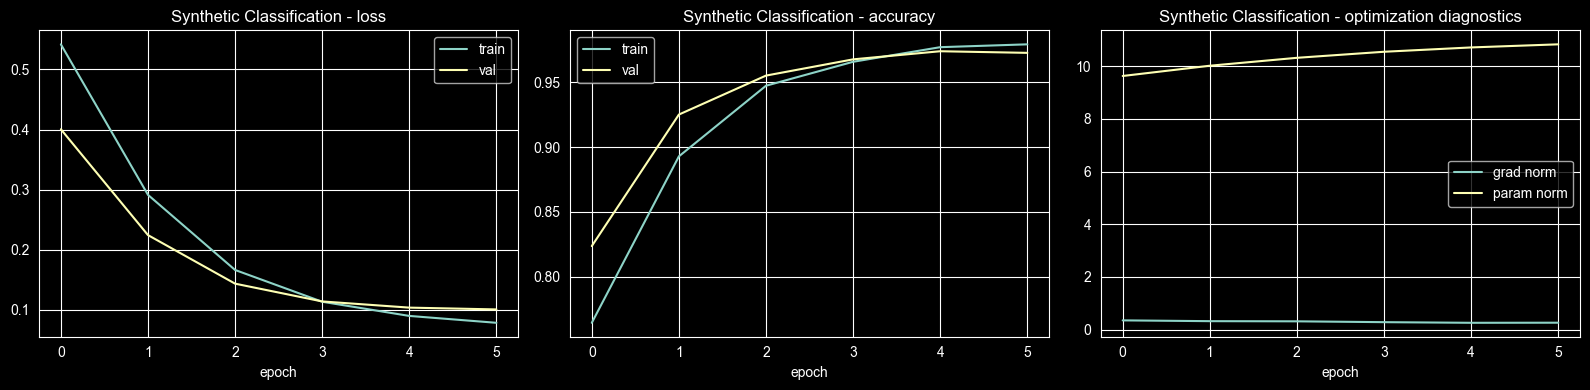

Final val accuracy: 0.9725


In [5]:
# Generate a classification dataset with moderate class separation to expose optimization behavior.
Xc, yc = make_classification(
    n_samples=4000,
    n_features=20,
    n_informative=12,
    n_redundant=4,
    class_sep=1.3,
    random_state=SEED
)

# Standardization aligns feature scales so gradients are not dominated by large-magnitude inputs.
Xc = StandardScaler().fit_transform(Xc)
Xc_tr, Xc_va, yc_tr, yc_va = train_test_split(Xc, yc, test_size=0.2, random_state=SEED)

# Convert arrays to tensors and construct mini-batch loaders.
train_ds = TensorDataset(torch.tensor(Xc_tr, dtype=torch.float32), torch.tensor(yc_tr, dtype=torch.long))
val_ds = TensorDataset(torch.tensor(Xc_va, dtype=torch.float32), torch.tensor(yc_va, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size)

# Build model with lesson-specific knobs (dropout, batch norm, init scheme, etc.).
model_cls = MLP(input_dim=20, output_dim=2, hidden_dim=cfg.hidden_dim, use_batch_norm=cfg.use_batch_norm, dropout_p=cfg.dropout_p).to(device)
apply_initialization(model_cls, cfg.init_scheme)

# Fit model and collect full history for interpretation.
history_cls = fit(
    model=model_cls,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=nn.CrossEntropyLoss(),
    cfg=cfg,
    task='classification',
    use_early_stopping=False
)

# Plot training curves and optimization diagnostics.
plot_history(history_cls, title='Synthetic Classification', metric_name='accuracy')

# Cache confidence and confusion-matrix data for downstream diagnostics section.
with torch.no_grad():
    logits_va = model_cls(torch.tensor(Xc_va, dtype=torch.float32).to(device))
    synthetic_cls_probs = torch.softmax(logits_va, dim=1)[:, 1].cpu().numpy()
    synthetic_cls_preds = logits_va.argmax(dim=1).cpu().numpy()
synthetic_cls_targets = yc_va
synthetic_cls_confusion = confusion_matrix(synthetic_cls_targets, synthetic_cls_preds)

print('Final val accuracy:', history_cls['val_metric'][-1])

### After the Code: Background + Why It Can Help

You now have both scalar metrics and distribution-level diagnostics, which is critical for explaining *why* a method helps.
Confidence histograms and confusion matrices often reveal calibration or class-specific weaknesses hidden by accuracy alone.

## Synthetic Data — Regression
Now test the same technique on regression to verify cross-task consistency.

### Before the Code: Purpose + Mechanics

This cell repeats the ablation on regression to test whether lesson benefits transfer beyond classification.
Background: robust techniques should improve optimization statistics across objective types, not only cross-entropy.

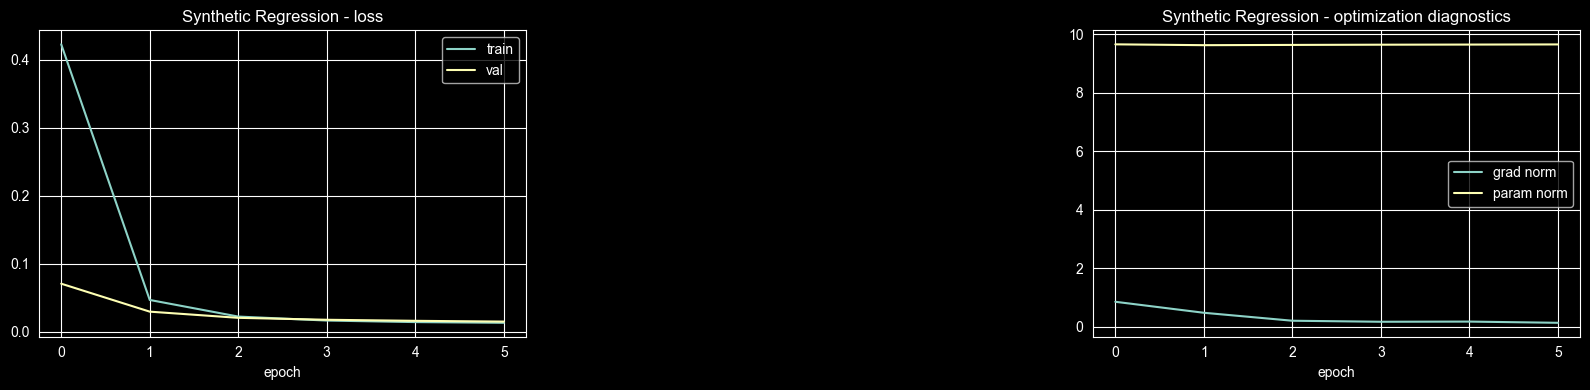

Best val MSE: 0.01474537311328782


In [6]:
# Generate regression data with controlled signal-to-noise ratio.
Xr, yr = make_regression(n_samples=4500, n_features=16, n_informative=10, noise=15.0, random_state=SEED)

# Scale inputs/targets so optimization operates on comparable numeric ranges.
Xr = StandardScaler().fit_transform(Xr)
yr = StandardScaler().fit_transform(yr.reshape(-1, 1)).reshape(-1)
Xr_tr, Xr_va, yr_tr, yr_va = train_test_split(Xr, yr, test_size=0.2, random_state=SEED)

# Create loaders for SGD/Adam updates.
train_ds_r = TensorDataset(torch.tensor(Xr_tr, dtype=torch.float32), torch.tensor(yr_tr, dtype=torch.float32))
val_ds_r = TensorDataset(torch.tensor(Xr_va, dtype=torch.float32), torch.tensor(yr_va, dtype=torch.float32))
train_loader_r = DataLoader(train_ds_r, batch_size=cfg.batch_size, shuffle=True)
val_loader_r = DataLoader(val_ds_r, batch_size=cfg.batch_size)

# Build and initialize the regression model under current lesson controls.
model_reg = MLP(input_dim=16, output_dim=1, hidden_dim=cfg.hidden_dim, use_batch_norm=cfg.use_batch_norm, dropout_p=cfg.dropout_p).to(device)
apply_initialization(model_reg, cfg.init_scheme)

# Train and visualize trajectory.
history_reg = fit(
    model=model_reg,
    train_loader=train_loader_r,
    val_loader=val_loader_r,
    criterion=nn.MSELoss(),
    cfg=cfg,
    task='regression',
    use_early_stopping=False
)
plot_history(history_reg, title='Synthetic Regression')

# Cache residual diagnostics for later plots.
with torch.no_grad():
    synthetic_reg_preds = model_reg(torch.tensor(Xr_va, dtype=torch.float32).to(device)).squeeze(1).cpu().numpy()
synthetic_reg_targets = yr_va
synthetic_reg_residuals = synthetic_reg_targets - synthetic_reg_preds

print('Best val MSE:', min(history_reg['val_loss']))

### After the Code: Background + Why It Can Help

Residuals expose bias patterns that aggregate MSE can hide, such as heteroscedasticity or systematic under/over-prediction.
If a method improves stability, you should often observe tighter residual distributions and smoother validation curves.

## Real Data — MNIST Classification
We now transfer the technique to MNIST to test behavior under higher-dimensional visual inputs.

### Before the Code: Purpose + Mechanics

This cell applies the technique to MNIST using a runtime-friendly subset while retaining enough samples to observe optimization effects.
Background: the flattening wrapper keeps model architecture constant so lesson comparisons stay focused on optimization/regularization methods.

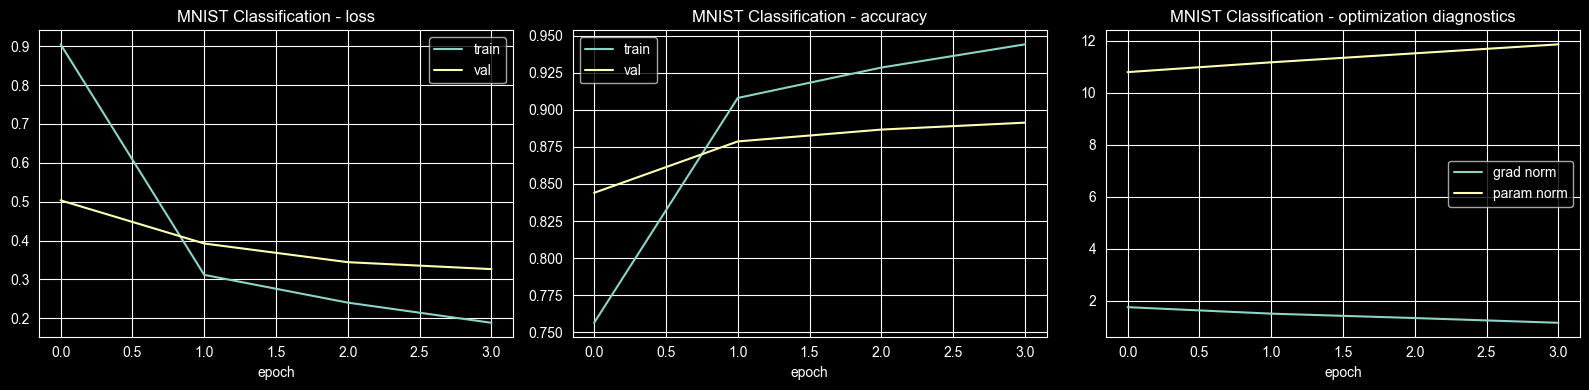

MNIST val accuracy: 0.8913333333333333


In [7]:
# Normalize MNIST so pixel intensities are centered, improving gradient conditioning.
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Keep runtime practical while preserving enough diversity for meaningful diagnostics.
subset_train = torch.utils.data.Subset(mnist_train, list(range(0, 6000)))
subset_val = torch.utils.data.Subset(mnist_test, list(range(0, 1500)))


def flatten_batch(batch):
    # MLP expects vectors; this reshapes 28x28 images into 784-dimensional features.
    x, y = batch
    return x.view(x.size(0), -1), y


train_loader_m = DataLoader(subset_train, batch_size=cfg.batch_size, shuffle=True)
val_loader_m = DataLoader(subset_val, batch_size=cfg.batch_size)


class FlattenLoader:
    # Lightweight wrapper to lazily flatten batches without materializing another dataset.
    def __init__(self, loader):
        self.loader = loader

    def __iter__(self):
        for batch in self.loader:
            yield flatten_batch(batch)

    def __len__(self):
        return len(self.loader)


train_loader_mf = FlattenLoader(train_loader_m)
val_loader_mf = FlattenLoader(val_loader_m)

# Build and initialize model under current lesson settings.
model_mnist = MLP(input_dim=28*28, output_dim=10, hidden_dim=cfg.hidden_dim, use_batch_norm=cfg.use_batch_norm, dropout_p=cfg.dropout_p).to(device)
apply_initialization(model_mnist, cfg.init_scheme)

# Reduce epoch count for MNIST to control notebook runtime while preserving instructional signal.
cfg_mnist = Config(**{**cfg.__dict__, 'epochs': max(4, cfg.epochs // 2)})
history_mnist = fit(
    model=model_mnist,
    train_loader=train_loader_mf,
    val_loader=val_loader_mf,
    criterion=nn.CrossEntropyLoss(),
    cfg=cfg_mnist,
    task='classification',
    use_early_stopping=False
)
plot_history(history_mnist, title='MNIST Classification', metric_name='accuracy')

# Cache class-level diagnostics for richer visual analysis.
mnist_logits_all, mnist_targets_chunks = [], []
with torch.no_grad():
    for xb, yb in val_loader_mf:
        logits = model_mnist(xb.to(device))
        mnist_logits_all.append(logits.cpu())
        mnist_targets_chunks.append(yb)

mnist_logits_all = torch.cat(mnist_logits_all, dim=0)
mnist_targets = torch.cat(mnist_targets_chunks, dim=0).numpy()
mnist_probs = torch.softmax(mnist_logits_all, dim=1).numpy()
mnist_preds = mnist_probs.argmax(axis=1)
mnist_confusion = confusion_matrix(mnist_targets, mnist_preds)

print('MNIST val accuracy:', history_mnist['val_metric'][-1])

### After the Code: Background + Why It Can Help

This gives a realistic benchmark where initialization/normalization often improve early-epoch stability and convergence speed.
Stored logits and confusion matrix enable class-wise error analysis beyond top-line accuracy.

## Real Data — California Housing Regression
We verify the same method on tabular real-world regression.

### Before the Code: Purpose + Mechanics

This cell evaluates the same method on California Housing to test generalization on real tabular regression.
Background: tabular data often exposes overfitting and feature-scale sensitivity, making it ideal for studying regularization dynamics.

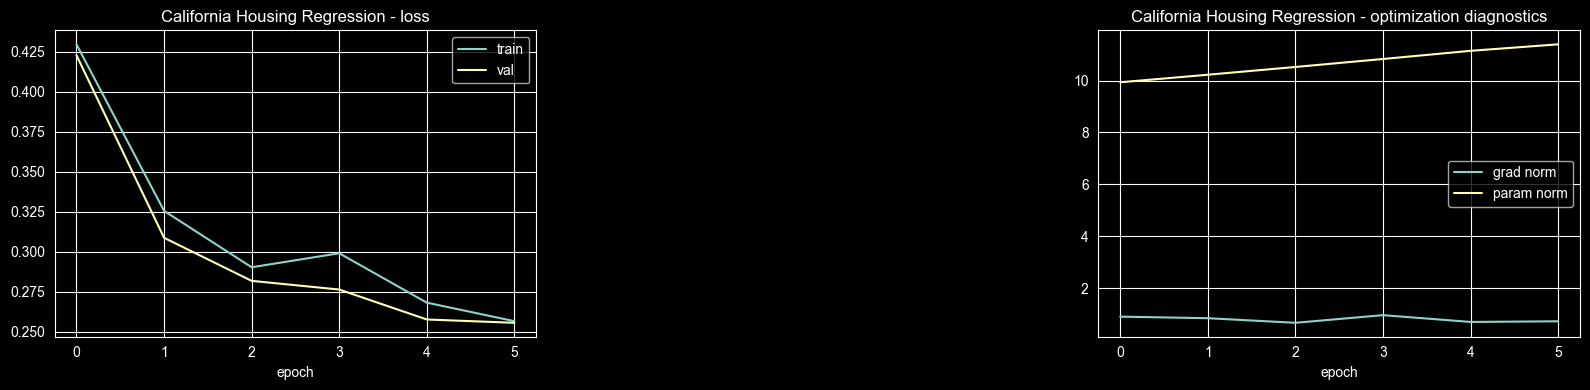

California Housing best val MSE (scaled): 0.25560127568337343


In [8]:
# Load a canonical real-world regression dataset.
cal = fetch_california_housing(as_frame=True)
Xh = cal.data.values
yh = cal.target.values

# Split before scaling to prevent validation leakage.
Xh_tr, Xh_va, yh_tr, yh_va = train_test_split(Xh, yh, test_size=0.2, random_state=SEED)
scaler_x = StandardScaler().fit(Xh_tr)
scaler_y = StandardScaler().fit(yh_tr.reshape(-1, 1))

# Apply train-fitted scaling to train and validation partitions.
Xh_tr = scaler_x.transform(Xh_tr)
Xh_va = scaler_x.transform(Xh_va)
yh_tr = scaler_y.transform(yh_tr.reshape(-1, 1)).reshape(-1)
yh_va = scaler_y.transform(yh_va.reshape(-1, 1)).reshape(-1)

# Build loaders to feed stochastic mini-batches.
train_h = TensorDataset(torch.tensor(Xh_tr, dtype=torch.float32), torch.tensor(yh_tr, dtype=torch.float32))
val_h = TensorDataset(torch.tensor(Xh_va, dtype=torch.float32), torch.tensor(yh_va, dtype=torch.float32))
train_loader_h = DataLoader(train_h, batch_size=cfg.batch_size, shuffle=True)
val_loader_h = DataLoader(val_h, batch_size=cfg.batch_size)

# Build and initialize model with the same lesson configuration.
model_h = MLP(input_dim=Xh_tr.shape[1], output_dim=1, hidden_dim=cfg.hidden_dim, use_batch_norm=cfg.use_batch_norm, dropout_p=cfg.dropout_p).to(device)
apply_initialization(model_h, cfg.init_scheme)

# Train, track diagnostics, and visualize learning trajectory.
history_h = fit(
    model=model_h,
    train_loader=train_loader_h,
    val_loader=val_loader_h,
    criterion=nn.MSELoss(),
    cfg=cfg,
    task='regression',
    use_early_stopping=False
)
plot_history(history_h, title='California Housing Regression')

# Store residuals for error-distribution plots in diagnostics section.
with torch.no_grad():
    housing_pred = model_h(torch.tensor(Xh_va, dtype=torch.float32).to(device)).squeeze(1).cpu().numpy()
housing_true = yh_va
housing_residuals = housing_true - housing_pred

print('California Housing best val MSE (scaled):', min(history_h['val_loss']))

### After the Code: Background + Why It Can Help

Scaling and leakage-free preprocessing are crucial for stable optimization and trustworthy validation estimates.
Residual diagnostics from this cell make it possible to analyze whether a technique improves not only average error but also error structure.

## Visualizations and Diagnostics
Use these diagnostics to explain *why* a technique helped or hurt, not just whether the final metric improved.

### Before the Code: Purpose + Mechanics

This code builds a multi-panel dashboard for optimization dynamics across synthetic and real tasks.
Background: plotting losses, gradient norms, and generalization gaps together helps identify whether gains come from faster fitting, better regularization, or both.

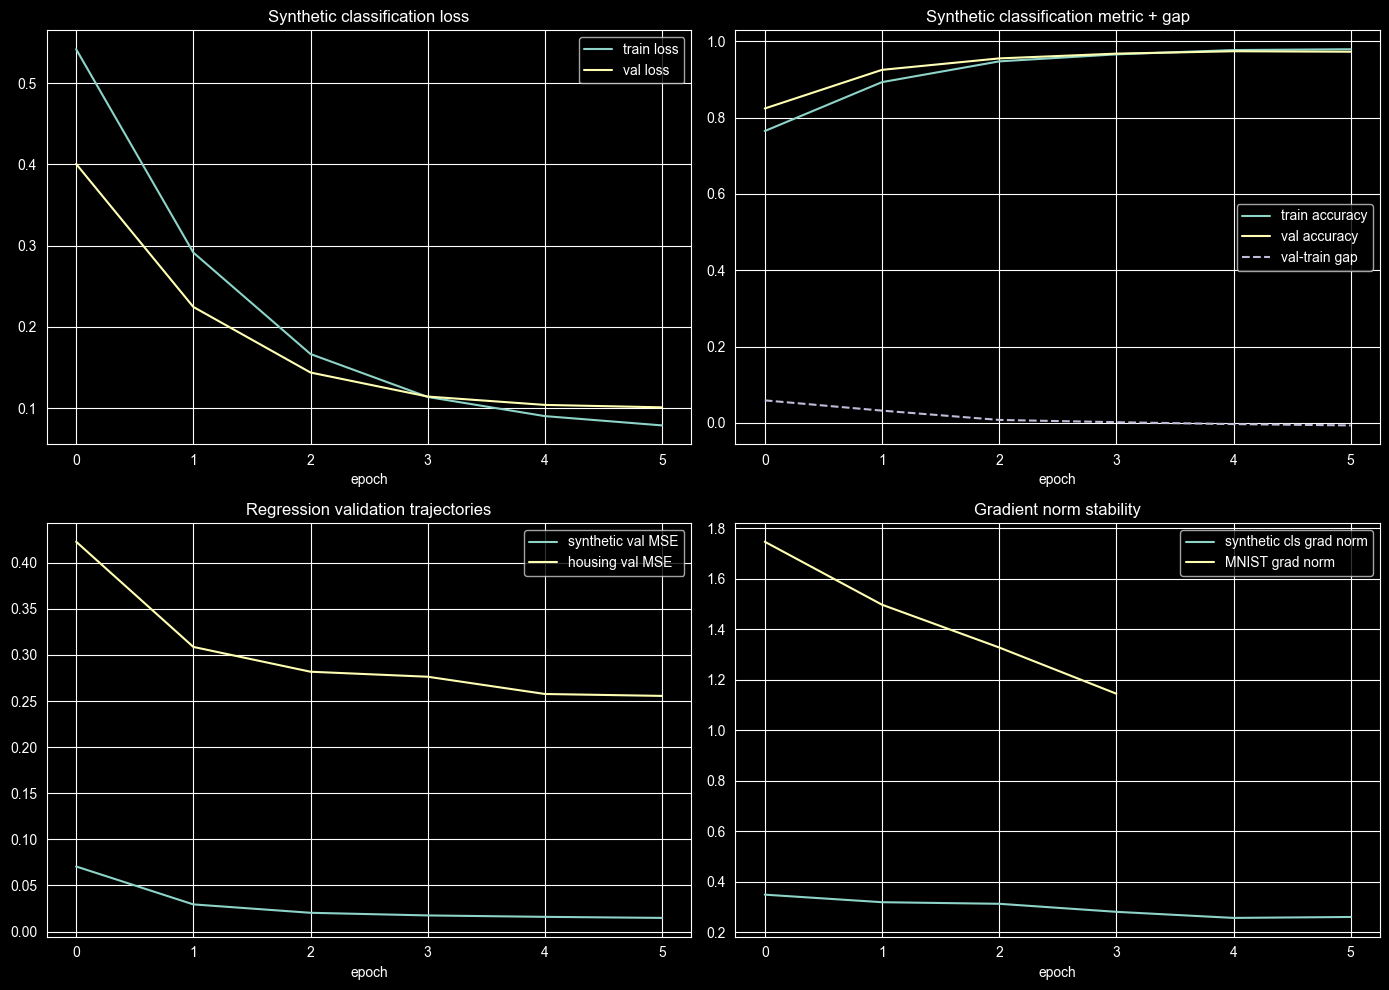

In [9]:
# Build a 2x2 dashboard showing optimization dynamics across tasks.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: synthetic classification loss curves.
axes[0, 0].plot(history_cls['train_loss'], label='train loss')
axes[0, 0].plot(history_cls['val_loss'], label='val loss')
axes[0, 0].set_title('Synthetic classification loss')
axes[0, 0].set_xlabel('epoch')
axes[0, 0].legend()

# Panel 2: synthetic classification accuracy + generalization gap.
axes[0, 1].plot(history_cls['train_metric'], label='train accuracy')
axes[0, 1].plot(history_cls['val_metric'], label='val accuracy')
axes[0, 1].plot(history_cls['generalization_gap'], label='val-train gap', linestyle='--')
axes[0, 1].set_title('Synthetic classification metric + gap')
axes[0, 1].set_xlabel('epoch')
axes[0, 1].legend()

# Panel 3: regression validation loss comparison.
axes[1, 0].plot(history_reg['val_loss'], label='synthetic val MSE')
axes[1, 0].plot(history_h['val_loss'], label='housing val MSE')
axes[1, 0].set_title('Regression validation trajectories')
axes[1, 0].set_xlabel('epoch')
axes[1, 0].legend()

# Panel 4: optimization stability via gradient norms.
axes[1, 1].plot(history_cls['train_grad_norm'], label='synthetic cls grad norm')
axes[1, 1].plot(history_mnist['train_grad_norm'], label='MNIST grad norm')
axes[1, 1].set_title('Gradient norm stability')
axes[1, 1].set_xlabel('epoch')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### After the Code: Background + Why It Can Help

Interpretation prompts:
1. Does the method reduce gradient spikes (stability) or mainly shift the final plateau (accuracy)?
2. Does the train/val gap contract, suggesting improved regularization?
3. Are gains consistent across synthetic and real datasets?

### Before the Code: Purpose + Mechanics

This code adds distribution-level diagnostics: confidence histograms, confusion heatmaps, and residual analyses.
Background: these visualizations reveal calibration and error-shape effects that scalar metrics often miss.

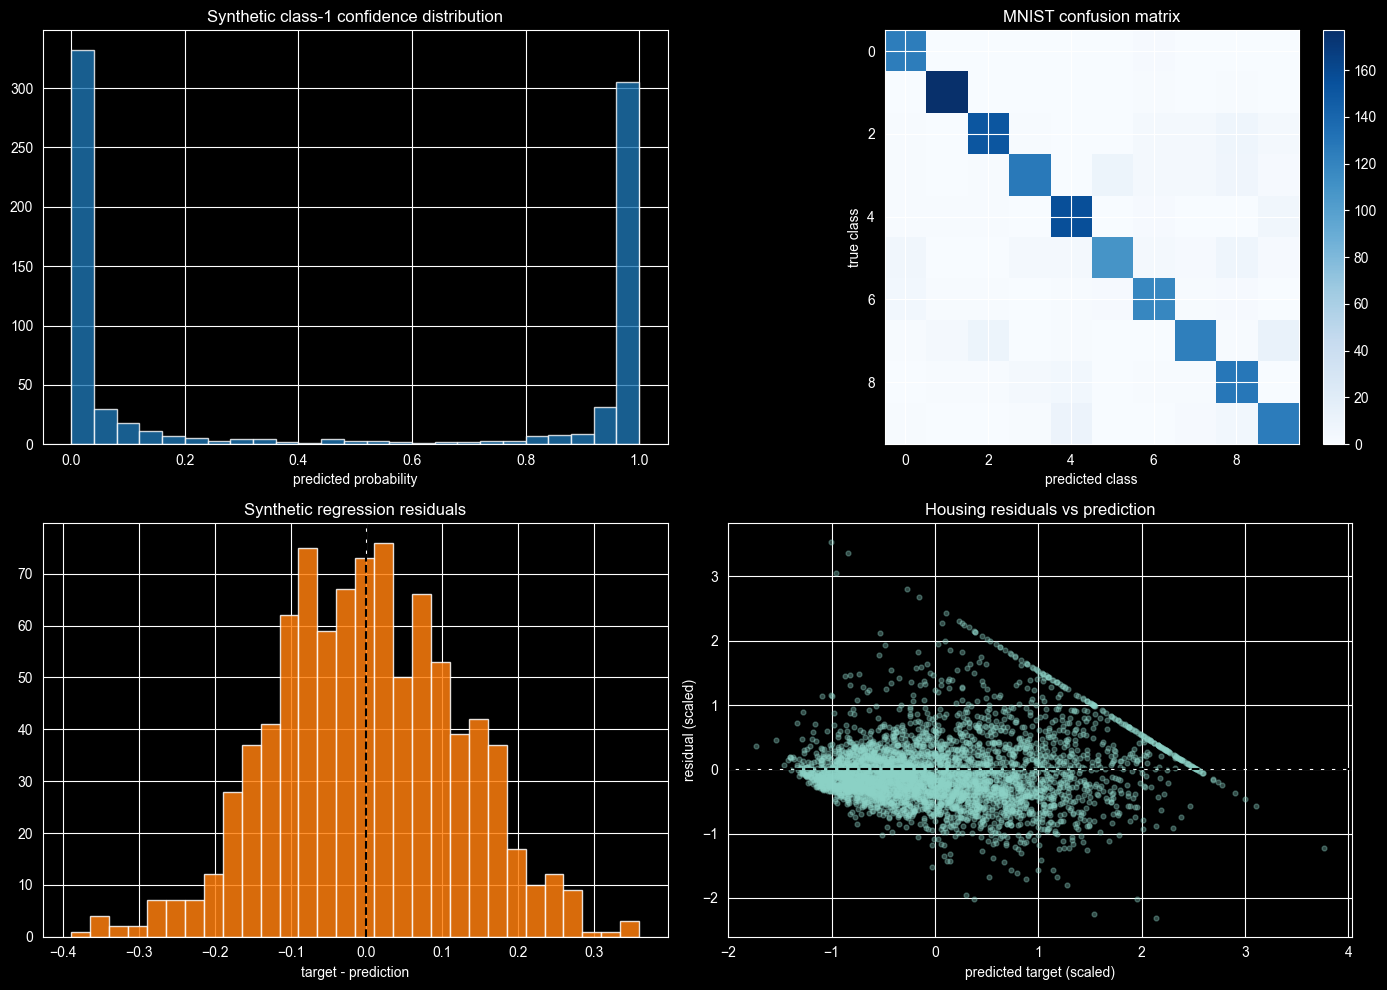

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confidence distribution can expose overconfidence or underconfidence.
axes[0, 0].hist(synthetic_cls_probs, bins=25, alpha=0.8, color='tab:blue')
axes[0, 0].set_title('Synthetic class-1 confidence distribution')
axes[0, 0].set_xlabel('predicted probability')

# Confusion matrix highlights which classes are hardest on MNIST.
im = axes[0, 1].imshow(mnist_confusion, cmap='Blues')
axes[0, 1].set_title('MNIST confusion matrix')
axes[0, 1].set_xlabel('predicted class')
axes[0, 1].set_ylabel('true class')
plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Residual histogram checks bias and spread for synthetic regression.
axes[1, 0].hist(synthetic_reg_residuals, bins=30, alpha=0.85, color='tab:orange')
axes[1, 0].axvline(0.0, color='black', linestyle='--')
axes[1, 0].set_title('Synthetic regression residuals')
axes[1, 0].set_xlabel('target - prediction')

# Residual-vs-prediction plot checks heteroscedasticity on housing.
axes[1, 1].scatter(housing_pred, housing_residuals, alpha=0.35, s=12)
axes[1, 1].axhline(0.0, color='black', linestyle='--')
axes[1, 1].set_title('Housing residuals vs prediction')
axes[1, 1].set_xlabel('predicted target (scaled)')
axes[1, 1].set_ylabel('residual (scaled)')

plt.tight_layout()
plt.show()

### After the Code: Background + Why It Can Help

Interpretation prompts:
1. Are confidence values concentrated near 0/1 (possible overconfidence) or well spread?
2. Which MNIST classes dominate confusion, and what feature patterns might explain that?
3. Do residuals show asymmetry or variance growth with prediction magnitude?

## Optuna Study (Technique-Specific)
This section is required for lesson 06 and optional for others.

### Before the Code: Purpose + Mechanics

This section runs a compact Optuna study to demonstrate adaptive hyperparameter search under runtime constraints.
Background: automated search can improve accuracy while pruning weak configurations to save compute.

In [11]:
def optuna_objective(trial):
    # Sample candidate hyperparameters from structured search spaces.
    trial_cfg = Config(
        hidden_dim=trial.suggest_categorical('hidden_dim', [64, 128, 192]),
        lr=trial.suggest_float('lr', 1e-4, 3e-3, log=True),
        dropout_p=trial.suggest_float('dropout_p', 0.0, 0.5),
        weight_decay=trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
        epochs=4,  # Keep objective lightweight for classroom runtime.
        batch_size=128,
    )

    # Use a synthetic proxy objective to compare trials quickly.
    X, y = make_classification(n_samples=1800, n_features=16, n_informative=10, random_state=SEED)
    X = StandardScaler().fit_transform(X)
    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=SEED)

    tr = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
    va = TensorDataset(torch.tensor(X_va, dtype=torch.float32), torch.tensor(y_va, dtype=torch.long))
    tr_loader = DataLoader(tr, batch_size=trial_cfg.batch_size, shuffle=True)
    va_loader = DataLoader(va, batch_size=trial_cfg.batch_size)

    # Train model and return validation objective for Optuna's sampler/pruner.
    model = MLP(input_dim=16, output_dim=2, hidden_dim=trial_cfg.hidden_dim, dropout_p=trial_cfg.dropout_p).to(device)
    hist = fit(model, tr_loader, va_loader, nn.CrossEntropyLoss(), trial_cfg, task='classification')
    score = min(hist['val_loss'])
    trial.report(score, step=0)
    return score


study = optuna.create_study(direction='minimize')
study.optimize(optuna_objective, n_trials=8)
print('Best trial:', study.best_trial.params, 'best val loss:', study.best_value)

[I 2026-03-03 10:38:14,358] A new study created in memory with name: no-name-2802acc7-94b3-4c0f-8926-e8e931abc7d1
[I 2026-03-03 10:38:14,438] Trial 0 finished with value: 0.5645642148123847 and parameters: {'hidden_dim': 192, 'lr': 0.00011257841466554376, 'dropout_p': 0.13508353079916785, 'weight_decay': 4.3758458338266764e-06}. Best is trial 0 with value: 0.5645642148123847.
[I 2026-03-03 10:38:14,483] Trial 1 finished with value: 0.5753281540340848 and parameters: {'hidden_dim': 128, 'lr': 0.0002127531610547768, 'dropout_p': 0.2526314073497515, 'weight_decay': 0.0001155501793900678}. Best is trial 0 with value: 0.5645642148123847.
[I 2026-03-03 10:38:14,522] Trial 2 finished with value: 0.6418014102511935 and parameters: {'hidden_dim': 64, 'lr': 0.00022453726941226203, 'dropout_p': 0.4264018958838876, 'weight_decay': 2.3512347732413852e-05}. Best is trial 0 with value: 0.5645642148123847.
[I 2026-03-03 10:38:14,562] Trial 3 finished with value: 0.6334301193555196 and parameters: {'hi

Best trial: {'hidden_dim': 64, 'lr': 0.0025856041722306143, 'dropout_p': 0.31900161507515656, 'weight_decay': 1.0920561439301753e-06} best val loss: 0.3439060442977481


### After the Code: Background + Why It Can Help

When this cell finishes, compare the best trial to baseline settings and ask which hyperparameters show highest sensitivity.
The main educational value is learning search-space design and efficient compute allocation, not just finding one number.

## Best Practices
- Constrain search ranges with domain knowledge.
- Log trial artifacts and seeds for reproducibility.
- Use pruning when trial cost is high.

## Common Pitfalls
- Applying a technique without a baseline comparison.
- Drawing conclusions from training loss only.
- Ignoring seed sensitivity and run-to-run variance.

## Exercises
### Level 1 — Easy (2-3)
1. Modify one core hyperparameter and describe exact effects on train/val curves.
2. Repeat with a second random seed and report variance.
3. Explain one equation term in your own words and connect it to one line of code.

### Level 2 — Medium (2-3)
1. Combine this technique with one previously covered method and evaluate synergy.
2. Debug an intentionally unstable setup (high learning rate / weak regularization).
3. Provide a short ablation table and interpretation.

### Level 3 — Hard (2)
1. Implement a from-scratch variant (without the convenience module where feasible).
2. Handle an edge case (tiny batch, noisy labels, class imbalance, or heavy-tailed targets).

### Level 4 — Kaggle Challenge (1)
Build a constrained pipeline with fixed compute budget and beat a target validation score.

### Before the Code: Purpose + Mechanics

Use this TODO scaffold to structure your own constrained competition-style experiment.
Background: explicitly connecting design choices to diagnostics prevents guess-and-check tuning.

In [12]:
# TODO (Kaggle Challenge):
# 1) Define a strict runtime budget and document hardware assumptions.
# 2) Train your best constrained model with fixed seed and logged hyperparameters.
# 3) Compare against baseline and justify each design choice with math + diagnostics.
# 4) Add one diagnostic plot that explains why your final model generalizes better.

### After the Code: Background + Why It Can Help

Treat this checklist as a mini research protocol.
A good answer reports both performance and mechanistic evidence from diagnostics.